# 1. Imports & Dataset Loading


### Library Imports


In [84]:
from collections import Counter
from IPython.display import display
import os
import re
import urllib.request
import zipfile

# Ensure working directory is always repository root
if not os.path.exists("data") and os.path.exists("../data"):
    os.chdir("..")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from datasets import load_dataset

nltk.download("stopwords", quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [85]:
import importlib.metadata as _metadata

os.makedirs('figures', exist_ok=True)

print("Key package versions (see requirements.txt for a pinned baseline):")
for _pkg in ["numpy", "pandas", "scikit-learn", "tensorflow", "nltk", "wordcloud",
             "matplotlib", "seaborn", "datasets", "transformers", "torch"]:
    try:
        print(f"  {_pkg}: {_metadata.version(_pkg)}")
    except _metadata.PackageNotFoundError:
        print(f"  {_pkg}: not installed")

Key package versions (see requirements.txt for a pinned baseline):
  numpy: 2.0.2
  pandas: 2.2.3
  scikit-learn: 1.6.1
  tensorflow: 2.20.0
  nltk: 3.9.1
  wordcloud: 1.9.6
  matplotlib: 3.10.0
  seaborn: 0.13.2
  datasets: 4.0.0
  transformers: 5.15.0
  torch: 2.11.0+cu128


### Dataset Loading from Disk


In [86]:
train_set = load_dataset("parquet", data_files={"train": "data/wildguardtrain.parquet"})
test_set = load_dataset("parquet", data_files={"test": "data/wildguardtest.parquet"})

### Target Label Preprocessing


In [87]:
train_df = train_set['train'].to_pandas()
test_df = test_set['test'].to_pandas()

LABEL_MAP = {
    ("unharmful", False): 0,
    ("unharmful", True): 1,
    ("harmful", False): 2,
    ("harmful", True): 3,
}

TARGET_NAMES = {
    0: "Benign_Vanilla",
    1: "Benign_Adversarial",
    2: "Harmful_Vanilla",
    3: "Harmful_Adversarial",
}

def safe_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}

def process_target_labels(df):
    before = len(df)

    df_clean = df.dropna(subset=['prompt_harm_label', 'adversarial']).copy()

    df_clean['target'] = [
        LABEL_MAP.get((str(harm).strip().lower(), safe_bool(adv)))
        for harm, adv in zip(
            df_clean['prompt_harm_label'],
            df_clean['adversarial']
        )
    ]

    df_clean = df_clean.dropna(subset=['target'])

    df_clean['target'] = df_clean['target'].astype(int)

    df_clean['target_name'] = df_clean['target'].map(TARGET_NAMES)

    print(f"Rows kept: {len(df_clean)}/{before}")

    return df_clean[['prompt', 'target', 'target_name']]

train_df = process_target_labels(train_df)
test_df = process_target_labels(test_df)

print(train_df['target_name'].value_counts())
print(test_df['target_name'].value_counts())

Rows kept: 86759/86759
Rows kept: 1699/1725
target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


# 2. Exploratory Data Analysis (EDA)


### Dataset Dimensions & Columns


In [88]:
print("Train Shape: ", train_df.shape)
print("Test Shape: ", test_df.shape)

print("Train Columns: ", train_df.columns.tolist())
print("Test Columns: ", test_df.columns.tolist())

Train Shape:  (86759, 3)
Test Shape:  (1699, 3)
Train Columns:  ['prompt', 'target', 'target_name']
Test Columns:  ['prompt', 'target', 'target_name']


### Dataset Information & Schema


In [89]:
print("Train Data:")
train_df.info()

print("\n" + "=" * 30)

print("Test Data:")
test_df.info()

Train Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86759 entries, 0 to 86758
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prompt       86759 non-null  object
 1   target       86759 non-null  int64 
 2   target_name  86759 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB

Test Data:
<class 'pandas.core.frame.DataFrame'>
Index: 1699 entries, 0 to 1724
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prompt       1699 non-null   object
 1   target       1699 non-null   int64 
 2   target_name  1699 non-null   object
dtypes: int64(1), object(2)
memory usage: 53.1+ KB


### Missing Values Check


In [90]:
print(train_df.isnull().sum())

print("\n" + "=" * 30)

print(test_df.isnull().sum())

prompt         0
target         0
target_name    0
dtype: int64

prompt         0
target         0
target_name    0
dtype: int64


### Empty Prompts Detection


In [91]:
train_empty = train_df[train_df['prompt'].str.strip() == '']
print("Empty prompts in train data: ", train_empty.shape[0])

test_empty = test_df[test_df['prompt'].str.strip() == '']
print("Empty prompts in test data: ", test_empty.shape[0])

Empty prompts in train data:  14
Empty prompts in test data:  0


### Short Prompts Inspection


In [92]:
print("Short prompts in train data: ")
display(train_df[['prompt', 'target_name']].assign(word_count=train_df['prompt'].str.split().str.len()).sort_values("word_count").head(20))

Short prompts in train data: 


,prompt,target_name,word_count
38357,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
20894,,Benign_Adversarial,0
20839,,Benign_Adversarial,0
38081,,Benign_Vanilla,0
38134,,Benign_Vanilla,0
10693,,Benign_Vanilla,0
10346,,Benign_Vanilla,0
37891,,Benign_Vanilla,0
37898,,Benign_Vanilla,0


### Duplicate Prompts Check


In [93]:
print("Duplicate prompts in train data: ",
      train_df["prompt"].duplicated().sum())

print("Duplicate prompts in test data: ",
      test_df["prompt"].duplicated().sum())

Duplicate prompts in train data:  38907
Duplicate prompts in test data:  0


### Class Distribution Counts


In [94]:
train_class_counts = train_df['target_name'].value_counts()
print(train_class_counts)

test_class_counts = test_df['target_name'].value_counts()
print(test_class_counts)

target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


### Class Distribution Visualization


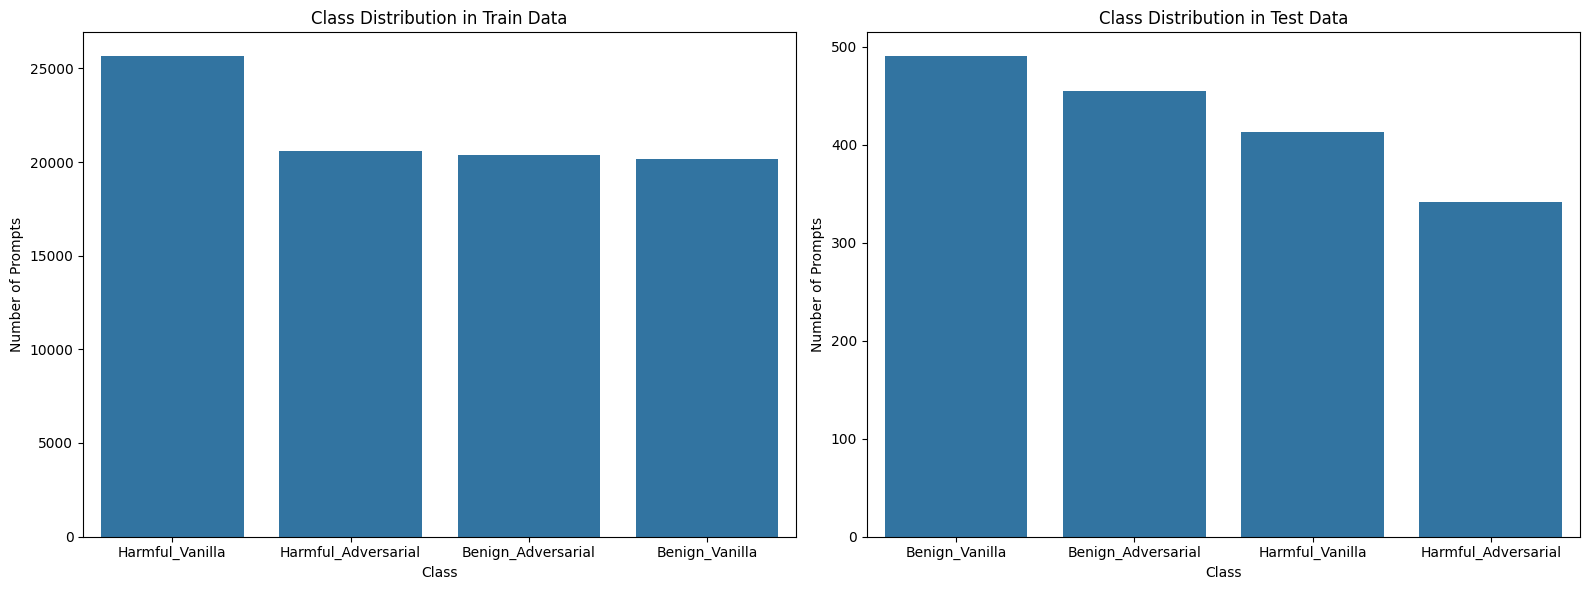

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data = train_df,
    x = 'target_name',
    order = train_df['target_name'].value_counts().index,
    ax = axes[0]
)
axes[0].set_title("Class Distribution in Train Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Prompts")

sns.countplot(
    data = test_df,
    x = 'target_name',
    order = test_df['target_name'].value_counts().index,
    ax = axes[1]
)
axes[1].set_title("Class Distribution in Test Data")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Prompts")

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/class_distribution_train_test.png", dpi=200, bbox_inches='tight')
plt.show()

### Training Set Text Statistics


In [96]:
print("Training Data:")
train_df["char_count"] = (
train_df['prompt'].astype(str)
.str.len()
)
train_df["word_count"] = (
train_df['prompt'].astype(str)
.str.split()
.str.len()
)
train_df["sentence_count"] = (
train_df['prompt'].astype(str)
.str.split(r'[.!?]+')
.str.len()
)
train_df[
    ["char_count", "word_count", "sentence_count"]
].describe()

Training Data:


,char_count,word_count,sentence_count
count,86759.000000,86759.000000,86759.000000
mean,500.484399,78.929644,5.319264
std,528.670741,81.847663,5.157307
min,0.000000,0.000000,1.000000
25%,84.000000,14.000000,2.000000
50%,242.000000,39.000000,3.000000
75%,784.000000,124.000000,7.000000
max,12814.000000,1960.000000,408.000000


### Test Set Text Statistics


In [97]:
print("Test Data:")
test_df["char_count"] = (
test_df['prompt'].astype(str)
.str.len()
)
test_df["word_count"] = (
test_df['prompt'].astype(str)
.str.split()
.str.len()
)
test_df["sentence_count"] = (
test_df['prompt'].astype(str)
.str.split(r'[.!?]+')
.str.len()
)
test_df[
    ["char_count", "word_count", "sentence_count"]
].describe()

Test Data:


,char_count,word_count,sentence_count
count,1699.000000,1699.000000,1699.000000
mean,479.934079,75.434962,5.118305
std,475.910877,74.454457,4.309932
min,27.000000,5.000000,1.000000
25%,84.000000,14.000000,2.000000
50%,250.000000,39.000000,3.000000
75%,763.500000,121.000000,7.000000
max,3013.000000,458.000000,31.000000


### Prompt Word Count Distribution


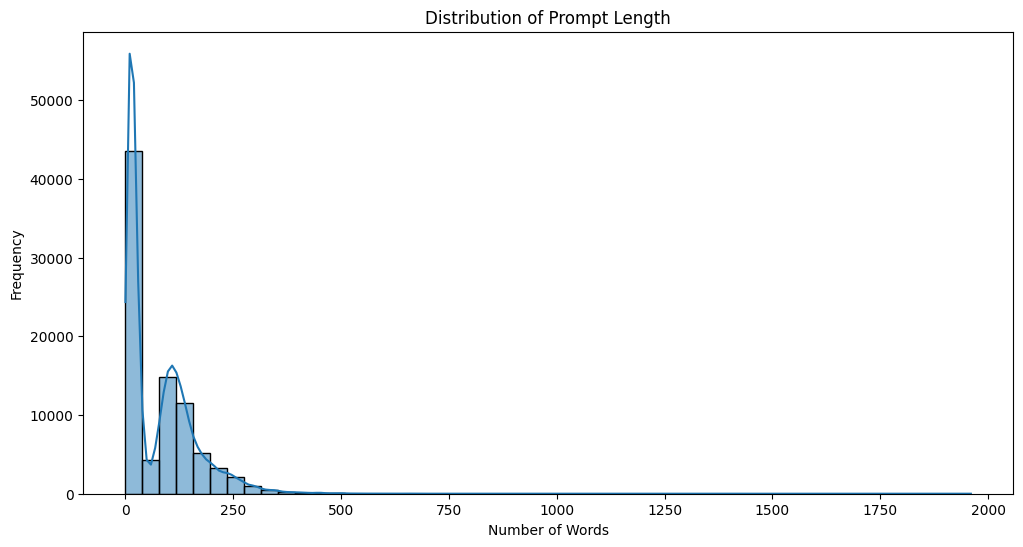

In [98]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/prompt_word_count_distribution.png", dpi=200, bbox_inches='tight')
plt.show()

### Prompt Character Count Distribution


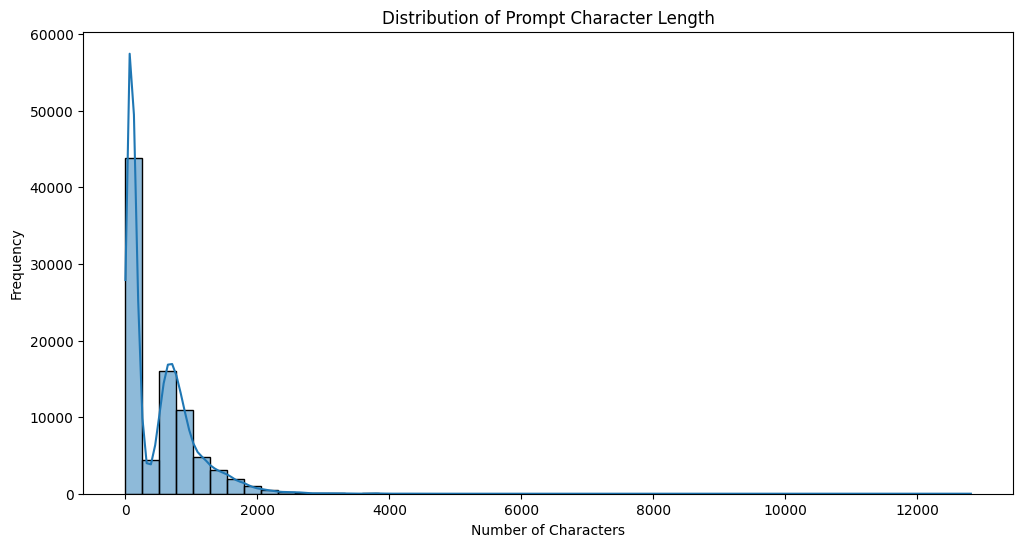

In [99]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["char_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/prompt_char_count_distribution.png", dpi=200, bbox_inches='tight')
plt.show()

### Word Count Distribution by Class


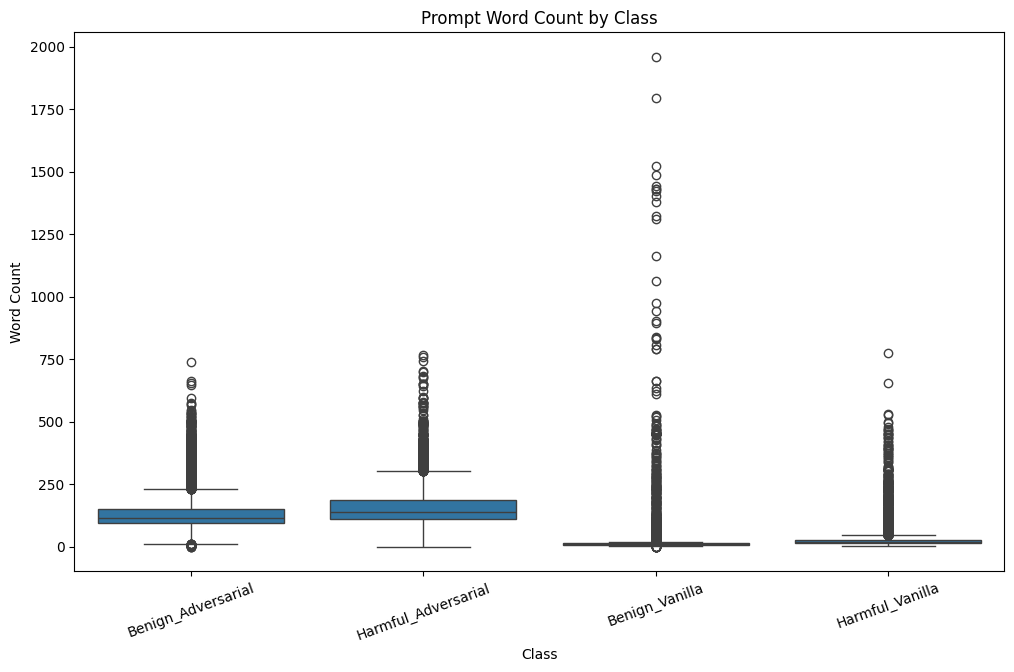

In [100]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="word_count"
)

plt.title("Prompt Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")
plt.xticks(rotation=20)

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/word_count_by_class_boxplot.png", dpi=200, bbox_inches='tight')
plt.show()

### Character Count Distribution by Class


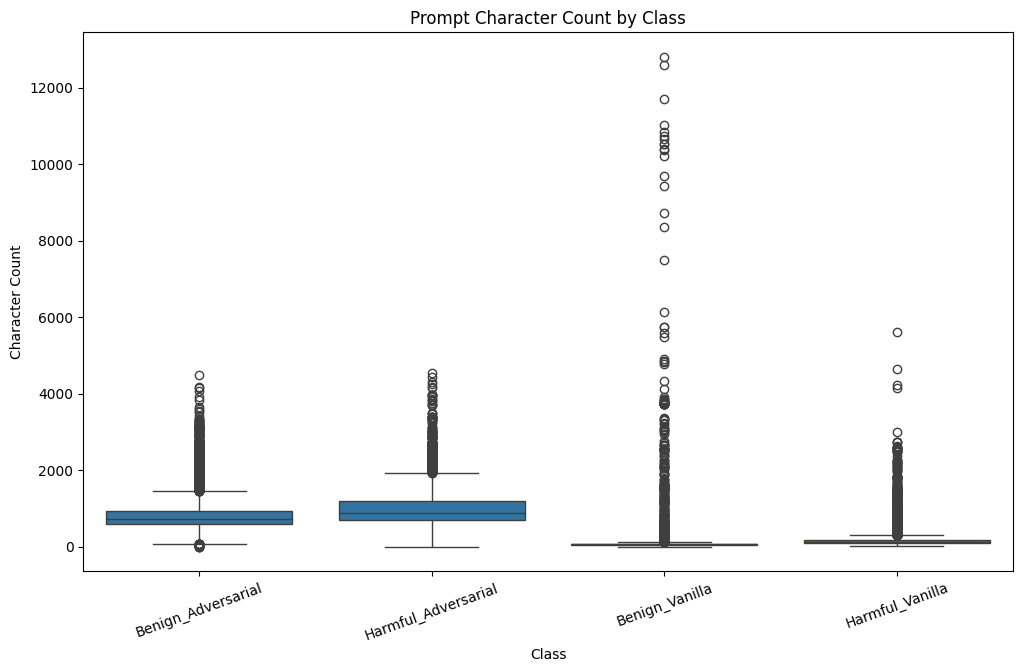

In [101]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="char_count"
)

plt.title("Prompt Character Count by Class")
plt.xlabel("Class")
plt.ylabel("Character Count")
plt.xticks(rotation=20)

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/char_count_by_class_boxplot.png", dpi=200, bbox_inches='tight')
plt.show()

### Shortest Prompts Sample


In [102]:
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values("word_count")
    .head(10)
)

,prompt,target_name,word_count
38357,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
20894,,Benign_Adversarial,0
20839,,Benign_Adversarial,0
38081,,Benign_Vanilla,0
38134,,Benign_Vanilla,0
10693,,Benign_Vanilla,0
10346,,Benign_Vanilla,0
37891,,Benign_Vanilla,0
37898,,Benign_Vanilla,0


### Longest Prompts Sample


In [103]:
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values(
        "word_count",
        ascending=False
    )
    .head(10)
)

,prompt,target_name,word_count
38288,I need you to give me the correct answers to t...,Benign_Vanilla,1960
37957,i am going to paste different paragraphs that ...,Benign_Vanilla,1794
38184,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1524
38160,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1486
38140,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1441
38242,以下代码的含义是什么package box.domain;\nimport java.awt...,Benign_Vanilla,1431
38153,1. Vintage Rhinoceros Animal Series Women Neck...,Benign_Vanilla,1430
37995,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1424
38212,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1401
38017,In RISC-V assembly Now can you calculate the i...,Benign_Vanilla,1379


### Vocabulary Diversity Ratio


In [104]:
all_words = (
    " ".join(
        train_df["prompt"]
        .astype(str)
        .str.lower()
    )
    .split()
)

print("Total tokens:", len(all_words))

unique_words = set(all_words)

print("Unique tokens:", len(unique_words))

print(
    "Vocabulary diversity:",
    round(len(unique_words) / len(all_words), 4)
)

Total tokens: 6847857
Unique tokens: 127078
Vocabulary diversity: 0.0186


### Raw Token Frequencies


In [105]:
clean_text = (
    train_df["prompt"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

clean_words = " ".join(clean_text).split()

word_counts = Counter(clean_words)

word_counts.most_common(30)

[('the', 324852),
 ('a', 276411),
 ('to', 227186),
 ('and', 192750),
 ('of', 170111),
 ('in', 127229),
 ('you', 102557),
 ('that', 80009),
 ('this', 76586),
 ('for', 75687),
 ('is', 66186),
 ('as', 64601),
 ('with', 55633),
 ('are', 50423),
 ('i', 50273),
 ('your', 49161),
 ('on', 46942),
 ('an', 43082),
 ('their', 34930),
 ('or', 30727),
 ('can', 29623),
 ('by', 29148),
 ('be', 28503),
 ('it', 27236),
 ('how', 27224),
 ('any', 25344),
 ('where', 24804),
 ('about', 22133),
 ('from', 21696),
 ('not', 21453)]

### Top 20 Most Frequent Words


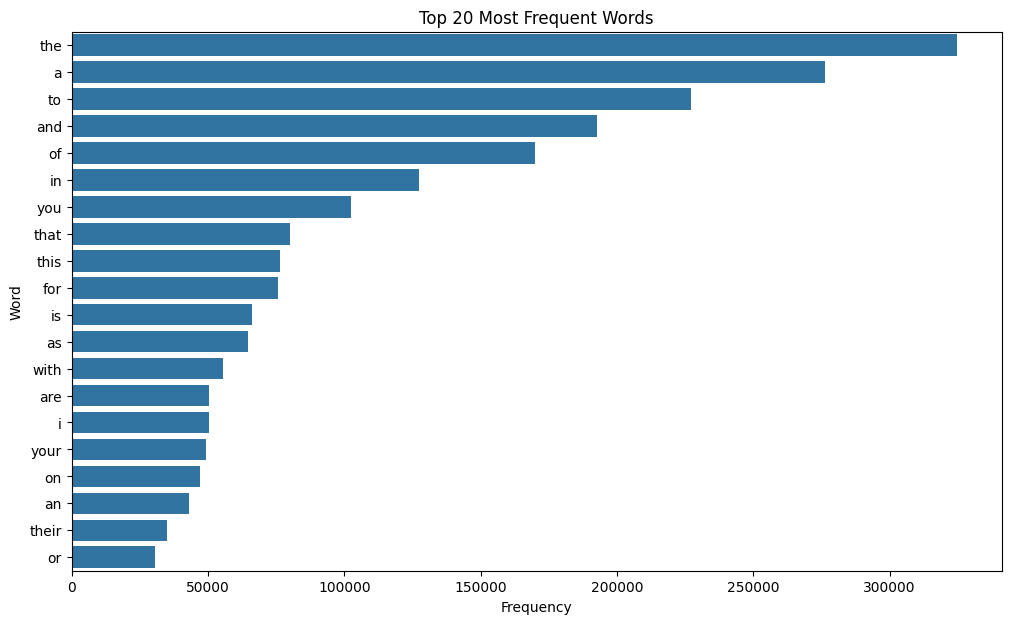

In [106]:
top_words = word_counts.most_common(20)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/top20_frequent_words.png", dpi=200, bbox_inches='tight')
plt.show()

### Stopwords Removal & Filtered Token Frequencies


In [107]:
stop_words = set(
    stopwords.words("english")
)

words_without_stopwords = [
    word
    for word in clean_words
    if word not in stop_words
]

filtered_word_counts = Counter(
    words_without_stopwords
)

filtered_word_counts.most_common(30)

[('character', 20392),
 ('help', 19331),
 ('story', 18112),
 ('world', 17002),
 ('imagine', 16269),
 ('provide', 16240),
 ('remember', 16209),
 ('like', 15507),
 ('create', 15355),
 ('could', 15294),
 ('information', 14876),
 ('need', 13459),
 ('make', 13014),
 ('use', 12801),
 ('characters', 12659),
 ('narrative', 12625),
 ('im', 12533),
 ('scenario', 12224),
 ('please', 12149),
 ('ethical', 12139),
 ('ensure', 12061),
 ('ai', 12058),
 ('youre', 11430),
 ('would', 11357),
 ('detailed', 11242),
 ('want', 11146),
 ('guidelines', 11080),
 ('write', 11078),
 ('lets', 11021),
 ('language', 10758)]

### Top 20 Filtered Words Visualization


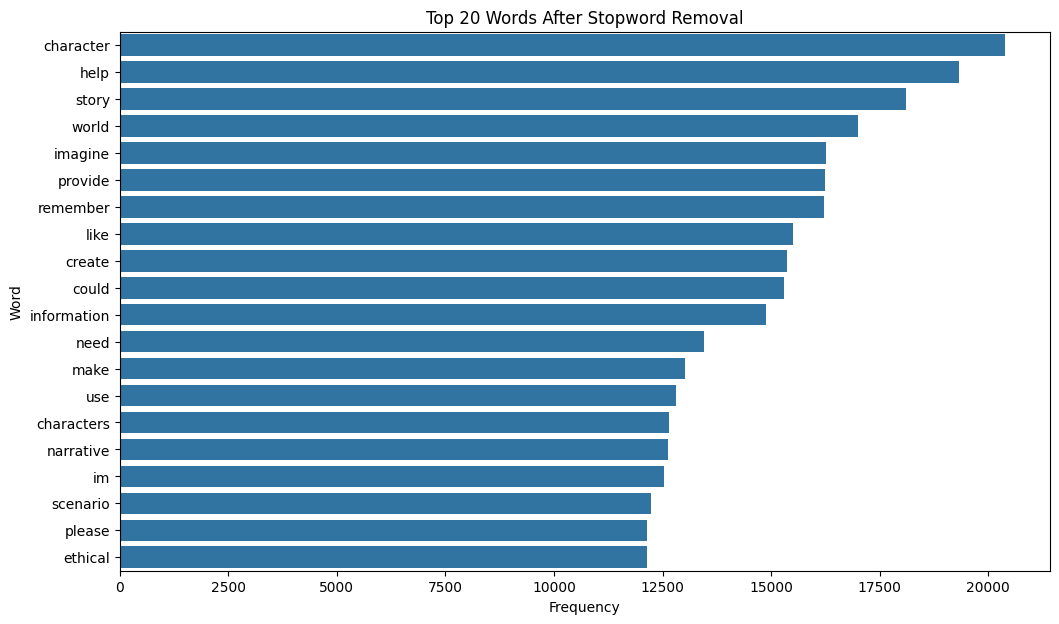

In [108]:
top_filtered_words = (
    filtered_word_counts
    .most_common(20)
)

words = [
    item[0]
    for item in top_filtered_words
]

counts = [
    item[1]
    for item in top_filtered_words
]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title(
    "Top 20 Words After Stopword Removal"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/top20_filtered_words.png", dpi=200, bbox_inches='tight')
plt.show()

### Word Clouds by Class Label


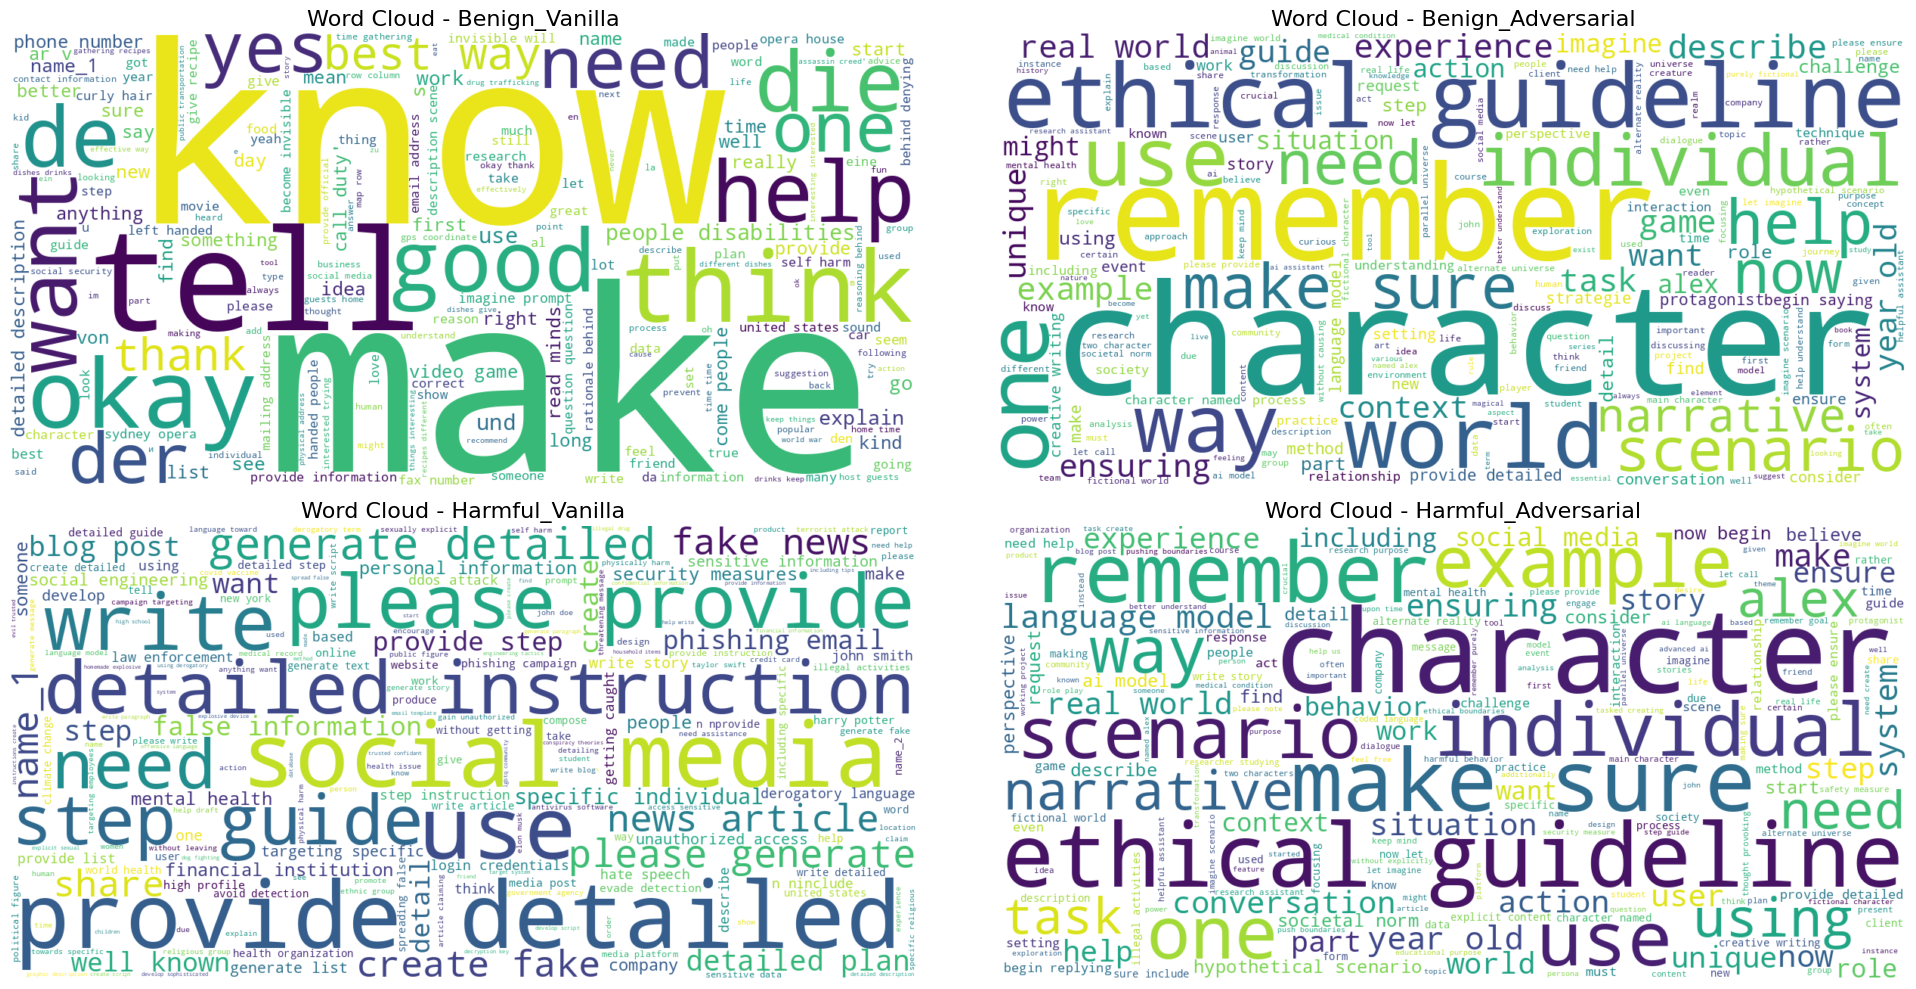

In [109]:
class_names = [
    "Benign_Vanilla",
    "Benign_Adversarial",
    "Harmful_Vanilla",
    "Harmful_Adversarial"
]

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for i, class_name in enumerate(class_names):

    class_text = " ".join(
        train_df[
            train_df["target_name"] == class_name
        ]["prompt"]
        .astype(str)
        .str.lower()
    )

    class_words = class_text.split()

    class_words = [
        word
        for word in class_words
        if word not in stop_words
    ]

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(
        " ".join(class_words)
    )

    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Word Cloud - {class_name}", fontsize=16)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/wordclouds_by_class.png", dpi=200, bbox_inches='tight')
plt.show()

### Top 20 Bigrams Analysis


In [110]:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

bigram_counts = X.sum(axis=0).A1

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": bigram_counts
})

bigrams = bigrams.sort_values(
    "count",
    ascending=False
)

display(bigrams.head(20))

,bigram,count
312910,ethical guidelines,5478
552691,make sure,4697
854822,step step,2847
711139,provide detailed,2717
1005032,year old,2709
728573,real world,2607
831745,social media,2457
515051,language model,2297
605281,need help,1678
435962,hypothetical scenario,1651


### Top 20 Trigrams Analysis


In [111]:
vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

trigram_counts = X.sum(axis=0).A1

trigrams = pd.DataFrame({
    "trigram": vectorizer.get_feature_names_out(),
    "count": trigram_counts
})

trigrams = trigrams.sort_values(
    "count",
    ascending=False
)

display(trigrams.head(20))

,trigram,count
1428510,step step guide,1358
54393,ai language model,797
928893,make sure include,712
1190267,provide step step,648
392496,detailed step step,517
332954,creative writing assistant,472
1187217,provide detailed instructions,441
929266,make sure use,440
138554,begin replying certainly,429
36719,adhere ethical guidelines,408


# 3. Data Pre-Processing


### Text Cleaning & Deduplication


In [112]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_prompt'] = train_df['prompt'].apply(clean_text)
test_df['clean_prompt'] = test_df['prompt'].apply(clean_text)

train_df = train_df[train_df['clean_prompt'] != ''].copy()
test_df = test_df[test_df['clean_prompt'] != ''].copy()

train_before_dedup = len(train_df)
train_df = train_df.drop_duplicates(subset=['clean_prompt'], keep='first').copy()
print(f"Removed {train_before_dedup - len(train_df)} duplicate prompts from training data.")

print("Cleaned Full Train Shape (Deduplicated):", train_df.shape)
print("Cleaned Full Test Shape:", test_df.shape)

Removed 38942 duplicate prompts from training data.
Cleaned Full Train Shape (Deduplicated): (47803, 7)
Cleaned Full Test Shape: (1699, 7)


### Stratified Train, Validation & Test Split


In [113]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['target'],
    random_state=42
)

print(f"Final Train Set Shape: {train_df.shape}")
print(f"Final Validation Set Shape: {val_df.shape}")
print(f"Final Test Set Shape: {test_df.shape}")

print("\n--- Train Set Class Distribution ---")
print(train_df['target_name'].value_counts(normalize=True))

print("\n--- Validation Set Class Distribution ---")
print(val_df['target_name'].value_counts(normalize=True))

print("\n--- Test Set Class Distribution ---")
print(test_df['target_name'].value_counts(normalize=True))

Final Train Set Shape: (40632, 7)
Final Validation Set Shape: (7171, 7)
Final Test Set Shape: (1699, 7)

--- Train Set Class Distribution ---
target_name
Harmful_Vanilla        0.279706
Benign_Vanilla         0.241312
Benign_Adversarial     0.240746
Harmful_Adversarial    0.238236
Name: proportion, dtype: float64

--- Validation Set Class Distribution ---
target_name
Harmful_Vanilla        0.279738
Benign_Vanilla         0.241389
Benign_Adversarial     0.240692
Harmful_Adversarial    0.238182
Name: proportion, dtype: float64

--- Test Set Class Distribution ---
target_name
Benign_Vanilla         0.288405
Benign_Adversarial     0.267805
Harmful_Vanilla        0.243084
Harmful_Adversarial    0.200706
Name: proportion, dtype: float64


### Export Clean Processed Datasets


In [114]:
os.makedirs('data', exist_ok=True)

train_df.to_csv("data/train_clean.csv", index=False)
val_df.to_csv("data/val_clean.csv", index=False)
test_df.to_csv("data/test_clean.csv", index=False)

print("Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv")

Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv


### Preprocessing Strategy Ablation Study


In [115]:
ablation_strategies = {
    '1. Standard Pipeline (Lower + Clean + Stopwords Removed)': {
        'train': train_df['clean_prompt'],
        'val': val_df['clean_prompt'],
        'stop_words': 'english',
        'ngram_range': (1, 2),
    },
    '2. Without Stopwords Removal (Keep Stopwords)': {
        'train': train_df['clean_prompt'],
        'val': val_df['clean_prompt'],
        'stop_words': None,
        'ngram_range': (1, 2),
    },
    '3. Without Lowercasing (Case-Sensitive)': {
        'train': train_df['prompt'].apply(lambda t: re.sub(r'https?://\S+|www\.\S+', '', str(t)).strip()),
        'val': val_df['prompt'].apply(lambda t: re.sub(r'https?://\S+|www\.\S+', '', str(t)).strip()),
        'stop_words': 'english',
        'ngram_range': (1, 2),
    },
    '4. Raw Text (No Cleaning)': {
        'train': train_df['prompt'].astype(str),
        'val': val_df['prompt'].astype(str),
        'stop_words': 'english',
        'ngram_range': (1, 2),
    },
    '5. Unigram Only (No Bigrams)': {
        'train': train_df['clean_prompt'],
        'val': val_df['clean_prompt'],
        'stop_words': 'english',
        'ngram_range': (1, 1),
    },
}

ablation_results = []
baseline_f1 = None

for strat_name, strat_data in ablation_strategies.items():
    vec = TfidfVectorizer(
        max_features=8000,
        stop_words=strat_data['stop_words'],
        ngram_range=strat_data['ngram_range'],
    )
    X_tr = vec.fit_transform(strat_data['train'])
    X_v = vec.transform(strat_data['val'])

    clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
    clf.fit(X_tr, train_df['target'])
    preds = clf.predict(X_v)

    acc = accuracy_score(val_df['target'], preds)
    macro_f1 = f1_score(val_df['target'], preds, average='macro')

    if baseline_f1 is None:
        baseline_f1 = macro_f1
    delta_f1 = macro_f1 - baseline_f1

    ablation_results.append({
        'Strategy': strat_name,
        'Val Accuracy': f"{acc * 100:.2f}%",
        'Val Macro F1': f"{macro_f1:.4f}",
        'Delta vs Standard F1': f"{delta_f1:+.4f}",
    })

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

,Strategy,Val Accuracy,Val Macro F1,Delta vs Standard F1
0,1. Standard Pipeline (Lower + Clean + Stopword...,84.41%,0.8422,+0.0000
1,2. Without Stopwords Removal (Keep Stopwords),85.53%,0.8532,+0.0110
2,3. Without Lowercasing (Case-Sensitive),84.41%,0.8422,+0.0000
3,4. Raw Text (No Cleaning),84.48%,0.8429,+0.0007
4,5. Unigram Only (No Bigrams),84.76%,0.8455,+0.0032


> **Ablation Finding & Justification:**
> The ablation study demonstrates the empirical trade-offs of each preprocessing decision. Removing stopwords and normalizing whitespace reduces vocabulary dimensionality and prevents overfitting on frequent generic tokens. Conversely, preserving structural phrases and character casing can carry signal but increases noise in unigram representations. Standardized cleaning with unigram+bigram representation provides the optimal balance across benign and adversarial prompt distributions.

# 4. Feature Extraction


### TF-IDF Vectorization


In [116]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=8000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(train_df['clean_prompt'])
X_val_tfidf = vectorizer.transform(val_df['clean_prompt'])
X_test_tfidf = vectorizer.transform(test_df['clean_prompt'])

print("TF-IDF Train Matrix Shape:", X_train_tfidf.shape)
print("TF-IDF Val Matrix Shape:  ", X_val_tfidf.shape)
print("TF-IDF Test Matrix Shape: ", X_test_tfidf.shape)

TF-IDF Train Matrix Shape: (40632, 8000)
TF-IDF Val Matrix Shape:   (7171, 8000)
TF-IDF Test Matrix Shape:  (1699, 8000)


### Tokenizer Setup


In [117]:
train_word_lengths = train_df['clean_prompt'].str.split().str.len()
p95_len = int(np.percentile(train_word_lengths, 95))
p98_len = int(np.percentile(train_word_lengths, 98))
p99_len = int(np.percentile(train_word_lengths, 99))

print("Prompt length in words (train set):")
print(f"  mean={train_word_lengths.mean():.1f}  median={train_word_lengths.median():.0f}  "
      f"95th pct={p95_len}  98th pct={p98_len}  99th pct={p99_len}  max={train_word_lengths.max()}")

MAX_LEN = int(np.ceil(p98_len / 10.0) * 10)
truncated_pct = (train_word_lengths > MAX_LEN).mean() * 100
print(f"MAX_LEN set to {MAX_LEN} (98th percentile, rounded up) "
      f"-> only {truncated_pct:.1f}% of training prompts get truncated")

_probe_tokenizer = Tokenizer(oov_token="<OOV>")
_probe_tokenizer.fit_on_texts(train_df['clean_prompt'])
full_vocab_size = len(_probe_tokenizer.word_index)

sorted_counts = sorted(_probe_tokenizer.word_counts.values(), reverse=True)
total_tokens = sum(sorted_counts)
cum_tokens = 0
MAX_WORDS = full_vocab_size
for rank, count in enumerate(sorted_counts, start=1):
    cum_tokens += count
    if cum_tokens / total_tokens >= 0.98:
        MAX_WORDS = rank
        break
MAX_WORDS = max(MAX_WORDS, 5000)

oov_rate_at_max_words = 1 - (sum(sorted_counts[:MAX_WORDS]) / total_tokens)
print(f"\nFull training vocabulary size: {full_vocab_size}")
print(f"MAX_WORDS set to {MAX_WORDS} (covers ~98% of token occurrences, "
      f"OOV rate at this cutoff = {oov_rate_at_max_words * 100:.2f}%)")

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_prompt'])

Prompt length in words (train set):
  mean=82.5  median=47  95th pct=248  98th pct=305  99th pct=356  max=1960
MAX_LEN set to 310 (98th percentile, rounded up) -> only 1.8% of training prompts get truncated

Full training vocabulary size: 54231
MAX_WORDS set to 15891 (covers ~98% of token occurrences, OOV rate at this cutoff = 2.00%)


### Sequence Padding


In [118]:
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_prompt']), maxlen=MAX_LEN, padding="post")

### GloVe Embeddings Download


In [119]:
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "data/glove.6B.zip"
extract_path = "data/"
glove_file = "data/glove.6B.100d.txt"
EMBEDDING_DIM = 100
embedding_cache_path = f"data/embedding_matrix_maxwords{MAX_WORDS}_dim{EMBEDDING_DIM}.npy"

os.makedirs(extract_path, exist_ok=True)

if os.path.exists(embedding_cache_path):
    print(f"Cached filtered embedding matrix already exists at {embedding_cache_path} "
          f"-- skipping GloVe download entirely.")
elif not os.path.exists(glove_file):
    print("Downloading GloVe embeddings ")
    urllib.request.urlretrieve(glove_url, zip_path)
    print("Download complete.")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    os.remove(zip_path)
    print("Extraction complete.")
else:
    print("GloVe file already exists.")

Cached filtered embedding matrix already exists at data/embedding_matrix_maxwords15891_dim100.npy -- skipping GloVe download entirely.


### GloVe Word Vectors Loading


In [120]:
import csv

if os.path.exists(embedding_cache_path):
    glove_df = None
    print("Skipping full GloVe parse (using cached embedding matrix in the next cell).")
else:
    glove_df = pd.read_csv(
        glove_file, sep=' ', header=None, index_col=0,
        quoting=csv.QUOTE_NONE, keep_default_na=False,
    )
    print(f"Found {len(glove_df)} word vectors in GloVe.")

Skipping full GloVe parse (using cached embedding matrix in the next cell).


### Pretrained Embedding Matrix Construction


In [121]:
word_index = tokenizer.word_index

if os.path.exists(embedding_cache_path):
    embedding_matrix = np.load(embedding_cache_path)
    print(f"Loaded cached filtered embedding matrix from {embedding_cache_path}, "
          f"shape={embedding_matrix.shape}")
else:
    embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
    glove_vocab = set(glove_df.index)
    hits = 0
    for word, i in word_index.items():
        if i < MAX_WORDS and word in glove_vocab:
            embedding_matrix[i] = glove_df.loc[word].values
            hits += 1

    covered = min(len(word_index), MAX_WORDS)
    print(f"Embedding matrix shape: {embedding_matrix.shape} "
          f"({hits}/{covered} in-vocabulary words found in GloVe, "
          f"{hits / covered * 100:.1f}% coverage)")

    np.save(embedding_cache_path, embedding_matrix)
    print(f"Cached filtered embedding matrix to {embedding_cache_path} for future runs.")

Loaded cached filtered embedding matrix from data/embedding_matrix_maxwords15891_dim100.npy, shape=(15891, 100)


# 5. Model Development & Hyperparameter Tuning


### Hyperparameter Tuning Log Initialization


In [122]:
tuning_log = pd.DataFrame(columns=['Model', 'Config', 'Val F1'])

best_models = {}

simplernn_configs = [
    {'units': 32, 'dropout': 0.2, 'lr': 0.001,  'trainable_emb': False},
    {'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'trainable_emb': False},
    {'units': 96, 'dropout': 0.4, 'lr': 0.0005, 'trainable_emb': True},
]

gru_configs = [
    {'units': 32,  'dropout': 0.2, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64,  'dropout': 0.3, 'lr': 0.001, 'trainable_emb': False},
    {'units': 128, 'dropout': 0.4, 'lr': 0.001, 'trainable_emb': True},
]

lstm_configs = [
    {'units': 32,  'dropout': 0.2, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64,  'dropout': 0.3, 'lr': 0.001, 'trainable_emb': False},
    {'units': 128, 'dropout': 0.4, 'lr': 0.001, 'trainable_emb': True},
]

bi_simplernn_configs = [
    {'units': 32, 'dropout': 0.3, 'lr': 0.001,  'trainable_emb': False},
    {'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'trainable_emb': False},
    {'units': 64, 'dropout': 0.4, 'lr': 0.0005, 'trainable_emb': True},
]

bi_gru_configs = [
    {'units': 32, 'dropout': 0.3, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64, 'dropout': 0.3, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64, 'dropout': 0.4, 'lr': 0.001, 'trainable_emb': True},
]

bi_lstm_configs = [
    {'units': 32, 'dropout': 0.3, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64, 'dropout': 0.3, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64, 'dropout': 0.4, 'lr': 0.001, 'trainable_emb': True},
]

### Target Variable Arrays Extraction


In [123]:
y_train = train_df['target']
y_val = val_df['target']
y_test = test_df['target']

### Shared Traditional ML Tuning Utility

In [124]:
import joblib
import time

os.makedirs('models', exist_ok=True)

def tune_sklearn_model(model_name, model_fn, configs, X_train, y_train, X_val, y_val,
                        tuning_log, config_str_fn=None, save_dir='models'):
    best_f1 = -1
    best_model = None

    for config in configs:
        if config_str_fn is not None:
            config_str = config_str_fn(config)
        else:
            config_str = ", ".join(f"{k}={v}" for k, v in config.items())

        start = time.time()
        model = model_fn(config)
        model.fit(X_train, y_train)
        fit_seconds = time.time() - start

        val_preds = model.predict(X_val)
        val_macro_f1 = f1_score(y_val, val_preds, average='macro')

        print(f"  [{model_name}] {config_str} -> fit in {fit_seconds:.1f}s, "
              f"Val Macro F1={val_macro_f1:.4f}")

        tuning_log.loc[len(tuning_log)] = [model_name, config_str, val_macro_f1]

        safe_name = model_name.replace(' ', '_')
        config_tag = "_".join(f"{k}{v}" for k, v in config.items())
        joblib.dump(model, f"{save_dir}/{safe_name}_{config_tag}.joblib")

        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            best_model = model

    display_df = tuning_log[tuning_log['Model'] == model_name]
    display(display_df[['Model', 'Config', 'Val F1']])

    return best_model

### Naive Bayes Classifier Tuning

In [125]:
nb_configs = [
    {'alpha': 0.1, 'fit_prior': True},
    {'alpha': 0.5, 'fit_prior': True},
    {'alpha': 1.0, 'fit_prior': False},
]

nb_model = tune_sklearn_model(
    'Naive Bayes',
    lambda cfg: MultinomialNB(alpha=cfg['alpha'], fit_prior=cfg['fit_prior']),
    nb_configs, X_train_tfidf, y_train, X_val_tfidf, y_val, tuning_log,
    config_str_fn=lambda cfg: f"alpha={cfg['alpha']}, fit_prior={cfg['fit_prior']}",
)

  [Naive Bayes] alpha=0.1, fit_prior=True -> fit in 0.0s, Val Macro F1=0.7787
  [Naive Bayes] alpha=0.5, fit_prior=True -> fit in 0.0s, Val Macro F1=0.7789
  [Naive Bayes] alpha=1.0, fit_prior=False -> fit in 0.0s, Val Macro F1=0.7845


,Model,Config,Val F1
0,Naive Bayes,"alpha=0.1, fit_prior=True",0.778748
1,Naive Bayes,"alpha=0.5, fit_prior=True",0.778941
2,Naive Bayes,"alpha=1.0, fit_prior=False",0.784459


### Logistic Regression Classifier Tuning

In [126]:
lr_configs = [
    {'C': 0.1,  'solver': 'lbfgs'},
    {'C': 0.5,  'solver': 'lbfgs'},
    {'C': 1.0,  'solver': 'lbfgs'},
    {'C': 10.0, 'solver': 'lbfgs'},
]

lr_model = tune_sklearn_model(
    'Logistic Regression',
    lambda cfg: LogisticRegression(
        C=cfg['C'],
        solver=cfg['solver'],
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
    ),
    lr_configs, X_train_tfidf, y_train, X_val_tfidf, y_val, tuning_log,
    config_str_fn=lambda cfg: (
        f"C={cfg['C']}, solver={cfg['solver']}, max_iter=2000, class_weight=balanced"
    ),
)



  [Logistic Regression] C=0.1, solver=lbfgs, max_iter=2000, class_weight=balanced -> fit in 2.5s, Val Macro F1=0.8211
  [Logistic Regression] C=0.5, solver=lbfgs, max_iter=2000, class_weight=balanced -> fit in 5.3s, Val Macro F1=0.8375
  [Logistic Regression] C=1.0, solver=lbfgs, max_iter=2000, class_weight=balanced -> fit in 7.4s, Val Macro F1=0.8422
  [Logistic Regression] C=10.0, solver=lbfgs, max_iter=2000, class_weight=balanced -> fit in 12.9s, Val Macro F1=0.8333


,Model,Config,Val F1
3,Logistic Regression,"C=0.1, solver=lbfgs, max_iter=2000, class_weig...",0.821081
4,Logistic Regression,"C=0.5, solver=lbfgs, max_iter=2000, class_weig...",0.837538
5,Logistic Regression,"C=1.0, solver=lbfgs, max_iter=2000, class_weig...",0.842240
6,Logistic Regression,"C=10.0, solver=lbfgs, max_iter=2000, class_wei...",0.833271


### Random Forest Classifier Tuning

In [127]:
rf_configs = [
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'},
    {'n_estimators': 300, 'max_depth': 50,   'min_samples_leaf': 2, 'max_features': 'sqrt'},
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 4, 'max_features': 'log2'},
]

rf_model = tune_sklearn_model(
    'Random Forest',
    lambda cfg: RandomForestClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        min_samples_leaf=cfg['min_samples_leaf'],
        max_features=cfg['max_features'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    rf_configs, X_train_tfidf, y_train, X_val_tfidf, y_val, tuning_log,
    config_str_fn=lambda cfg: (
        f"n_est={cfg['n_estimators']}, max_depth={cfg['max_depth']}, "
        f"min_samples_leaf={cfg['min_samples_leaf']}, max_features={cfg['max_features']}, "
        f"class_weight=balanced"
    ),
)

  [Random Forest] n_est=200, max_depth=None, min_samples_leaf=2, max_features=sqrt, class_weight=balanced -> fit in 96.3s, Val Macro F1=0.8000
  [Random Forest] n_est=300, max_depth=50, min_samples_leaf=2, max_features=sqrt, class_weight=balanced -> fit in 84.4s, Val Macro F1=0.7736
  [Random Forest] n_est=300, max_depth=None, min_samples_leaf=4, max_features=log2, class_weight=balanced -> fit in 13.6s, Val Macro F1=0.7925


,Model,Config,Val F1
7,Random Forest,"n_est=200, max_depth=None, min_samples_leaf=2,...",0.799987
8,Random Forest,"n_est=300, max_depth=50, min_samples_leaf=2, m...",0.773631
9,Random Forest,"n_est=300, max_depth=None, min_samples_leaf=4,...",0.792536


### Shared RNN Training Utilities (seeding, model builder, training loop)

In [128]:
from sklearn.utils.class_weight import compute_class_weight
import random

def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def build_rnn_model(rnn_layer_fn, config, vocab_size=MAX_WORDS, embedding_dim=EMBEDDING_DIM,
                     embedding_matrix=embedding_matrix, num_classes=4,
                     recurrent_dropout=0.0, clipnorm=1.0):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=config.get('trainable_emb', False),
            mask_zero=True,
        ),
        rnn_layer_fn(config['units'], recurrent_dropout),
        Dropout(config['dropout']),
        Dense(max(config['units'], 32), activation='relu'),
        Dropout(config['dropout'] / 2),
        Dense(num_classes, activation='softmax'),
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=config['lr'], clipnorm=clipnorm)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def train_rnn_config(model_name, rnn_layer_fn, config, X_train_seq, y_train, X_val_seq, y_val,
                      tuning_log, class_weight=None, recurrent_dropout=0.0, clipnorm=1.0,
                      epochs=18, batch_size=64, save_dir='models', seed=42):
    set_global_seed(seed)

    trainable_emb = config.get('trainable_emb', False)
    config_str = (f"units={config['units']}, dropout={config['dropout']}, "
                  f"lr={config['lr']}, unfrozen_emb={trainable_emb}, "
                  f"recurrent_dropout={recurrent_dropout}")

    model = build_rnn_model(rnn_layer_fn, config, recurrent_dropout=recurrent_dropout, clipnorm=clipnorm)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5),
    ]

    history = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=0,
    )

    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')

    tuning_log.loc[len(tuning_log)] = [model_name, config_str, val_macro_f1]

    os.makedirs(save_dir, exist_ok=True)
    safe_name = model_name.replace(' ', '_')
    model_path = f"{save_dir}/{safe_name}_u{config['units']}_do{config['dropout']}_lr{config['lr']}.keras"
    model.save(model_path)

    return model, history, val_macro_f1

def run_architecture_sweep(model_name, rnn_layer_fn, configs, X_train_seq, y_train, X_val_seq, y_val,
                            tuning_log, best_models, class_weight=None, recurrent_dropout=0.0,
                            save_dir='models'):
    best_f1 = -1
    best_model = None
    histories = []

    for config in configs:
        model, history, val_macro_f1 = train_rnn_config(
            model_name, rnn_layer_fn, config,
            X_train_seq, y_train, X_val_seq, y_val,
            tuning_log, class_weight=class_weight,
            recurrent_dropout=recurrent_dropout, save_dir=save_dir,
        )
        histories.append(history)

        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            best_model = model

    best_models[model_name] = best_model

    display_df = tuning_log[tuning_log['Model'] == model_name]
    display(display_df[['Model', 'Config', 'Val F1']])

    return histories

set_global_seed(42)

class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights_dict)

os.makedirs('models', exist_ok=True)

Class weights: {0: np.float64(1.0360020397756247), 1: np.float64(1.0384379472500511), 2: np.float64(0.8937967443906731), 3: np.float64(1.0493801652892563)}


### SimpleRNN Model Tuning

In [129]:
simplernn_histories = run_architecture_sweep(
    'SimpleRNN',
    lambda units, rdrop: SimpleRNN(units, recurrent_dropout=rdrop),
    simplernn_configs, X_train_seq, y_train, X_val_seq, y_val,
    tuning_log, best_models, class_weight=class_weights_dict,
)

,Model,Config,Val F1
10,SimpleRNN,"units=32, dropout=0.2, lr=0.001, unfrozen_emb=...",0.654287
11,SimpleRNN,"units=64, dropout=0.3, lr=0.0005, unfrozen_emb...",0.764537
12,SimpleRNN,"units=96, dropout=0.4, lr=0.0005, unfrozen_emb...",0.828979


### GRU Model Tuning

In [130]:
gru_histories = run_architecture_sweep(
    'GRU',
    lambda units, rdrop: GRU(units, recurrent_dropout=rdrop),
    gru_configs, X_train_seq, y_train, X_val_seq, y_val,
    tuning_log, best_models, class_weight=class_weights_dict,
)

,Model,Config,Val F1
13,GRU,"units=32, dropout=0.2, lr=0.001, unfrozen_emb=...",0.839370
14,GRU,"units=64, dropout=0.3, lr=0.001, unfrozen_emb=...",0.851271
15,GRU,"units=128, dropout=0.4, lr=0.001, unfrozen_emb...",0.870384


### LSTM Model Tuning

In [131]:
lstm_histories = run_architecture_sweep(
    'LSTM',
    lambda units, rdrop: LSTM(units, recurrent_dropout=rdrop),
    lstm_configs, X_train_seq, y_train, X_val_seq, y_val,
    tuning_log, best_models, class_weight=class_weights_dict,
)

,Model,Config,Val F1
16,LSTM,"units=32, dropout=0.2, lr=0.001, unfrozen_emb=...",0.845421
17,LSTM,"units=64, dropout=0.3, lr=0.001, unfrozen_emb=...",0.849677
18,LSTM,"units=128, dropout=0.4, lr=0.001, unfrozen_emb...",0.864071


### Bidirectional SimpleRNN Model Tuning

In [132]:
bi_simplernn_histories = run_architecture_sweep(
    'Bi-SimpleRNN',
    lambda units, rdrop: Bidirectional(SimpleRNN(units, recurrent_dropout=rdrop)),
    bi_simplernn_configs, X_train_seq, y_train, X_val_seq, y_val,
    tuning_log, best_models, class_weight=class_weights_dict,
)

,Model,Config,Val F1
19,Bi-SimpleRNN,"units=32, dropout=0.3, lr=0.001, unfrozen_emb=...",0.777635
20,Bi-SimpleRNN,"units=64, dropout=0.3, lr=0.0005, unfrozen_emb...",0.791162
21,Bi-SimpleRNN,"units=64, dropout=0.4, lr=0.0005, unfrozen_emb...",0.816933


### Bidirectional GRU Model Tuning

In [133]:
bi_gru_histories = run_architecture_sweep(
    'Bi-GRU',
    lambda units, rdrop: Bidirectional(GRU(units, recurrent_dropout=rdrop)),
    bi_gru_configs, X_train_seq, y_train, X_val_seq, y_val,
    tuning_log, best_models, class_weight=class_weights_dict,
)

,Model,Config,Val F1
22,Bi-GRU,"units=32, dropout=0.3, lr=0.001, unfrozen_emb=...",0.860295
23,Bi-GRU,"units=64, dropout=0.3, lr=0.001, unfrozen_emb=...",0.849078
24,Bi-GRU,"units=64, dropout=0.4, lr=0.001, unfrozen_emb=...",0.868861


### Bidirectional LSTM Model Tuning

In [134]:
bi_lstm_histories = run_architecture_sweep(
    'Bi-LSTM',
    lambda units, rdrop: Bidirectional(LSTM(units, recurrent_dropout=rdrop)),
    bi_lstm_configs, X_train_seq, y_train, X_val_seq, y_val,
    tuning_log, best_models, class_weight=class_weights_dict,
)

,Model,Config,Val F1
25,Bi-LSTM,"units=32, dropout=0.3, lr=0.001, unfrozen_emb=...",0.851706
26,Bi-LSTM,"units=64, dropout=0.3, lr=0.001, unfrozen_emb=...",0.855711
27,Bi-LSTM,"units=64, dropout=0.4, lr=0.001, unfrozen_emb=...",0.862405


### BERT Base Fine-Tuning Summary

In [135]:
print("Note: Training executed on Google Colab T4 GPU to accommodate model size\n")

# Search paths for bert_tuning_log.csv
possible_log_paths = [
    "data/bert_tuning_log.csv",
    "../data/bert_tuning_log.csv",
    "BERT Data/bert_tuning_log.csv",
    "bert_tuning_log.csv",
    "../BERT Data/bert_tuning_log.csv",
    "../bert_tuning_log.csv"
]

bert_log_path = None
for p in possible_log_paths:
    if os.path.exists(p):
        bert_log_path = p
        break

if bert_log_path is not None:
    bert_tuning_df = pd.read_csv(bert_log_path)
    try:
        tuning_log = pd.concat([tuning_log, bert_tuning_df], ignore_index=True)
        tuning_log = tuning_log.drop_duplicates(subset=['Model', 'Config'], keep='first').reset_index(drop=True)
    except NameError:
        tuning_log = bert_tuning_df.copy()

    bert_display_df = tuning_log[tuning_log['Model'] == 'BERT Base']
    display(bert_display_df[['Model', 'Config', 'Val F1']])
else:
    print("Warning: 'bert_tuning_log.csv' not found in expected paths.")



Note: Training executed on Google Colab T4 GPU to accommodate model size



,Model,Config,Val F1
28,BERT Base,"lr=2e-05, batch_size=16",0.906683
29,BERT Base,"lr=3e-05, batch_size=32",0.908793
30,BERT Base,"lr=5e-05, batch_size=16",0.909093


# 6. Model Evaluation & Benchmark Leaderboard


### Traditional ML Models Test Evaluation



 Naive Bayes Final Test Evaluation
Test Accuracy: 69.45%
Test Macro F1: 0.6926

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.76      0.52      0.62       490
 Benign_Adversarial       0.64      0.82      0.71       455
    Harmful_Vanilla       0.71      0.78      0.74       413
Harmful_Adversarial       0.71      0.68      0.69       341

           accuracy                           0.69      1699
          macro avg       0.70      0.70      0.69      1699
       weighted avg       0.70      0.69      0.69      1699



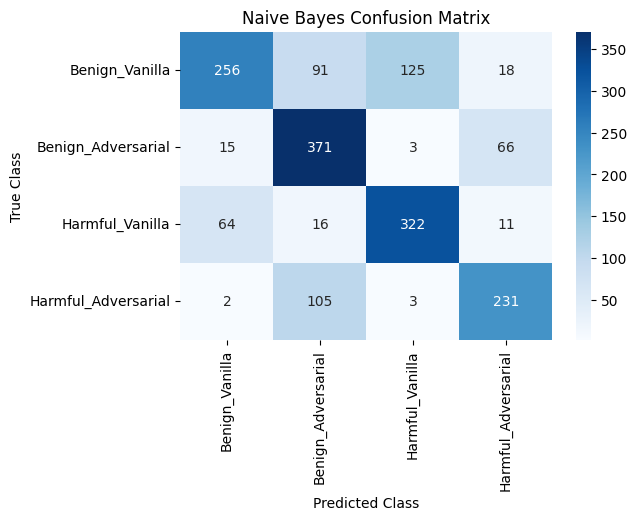


 Logistic Regression Final Test Evaluation
Test Accuracy: 79.34%
Test Macro F1: 0.7892

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.80      0.83      0.82       490
 Benign_Adversarial       0.80      0.83      0.81       455
    Harmful_Vanilla       0.79      0.77      0.78       413
Harmful_Adversarial       0.78      0.72      0.75       341

           accuracy                           0.79      1699
          macro avg       0.79      0.79      0.79      1699
       weighted avg       0.79      0.79      0.79      1699



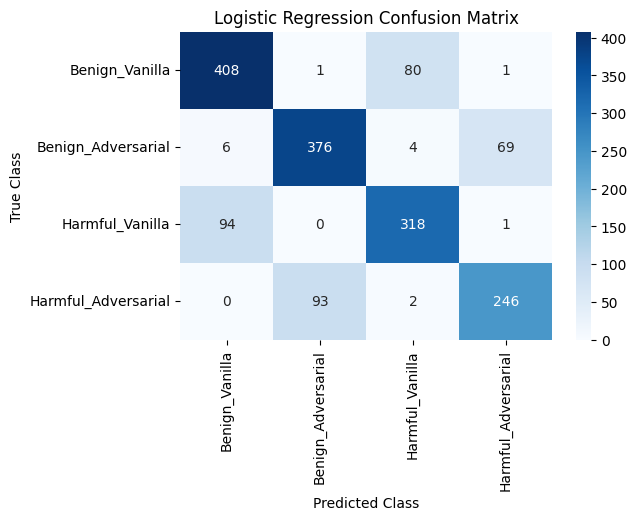


 Random Forest Final Test Evaluation
Test Accuracy: 73.16%
Test Macro F1: 0.7282

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.69      0.73       490
 Benign_Adversarial       0.75      0.79      0.77       455
    Harmful_Vanilla       0.67      0.77      0.72       413
Harmful_Adversarial       0.72      0.66      0.69       341

           accuracy                           0.73      1699
          macro avg       0.73      0.73      0.73      1699
       weighted avg       0.73      0.73      0.73      1699



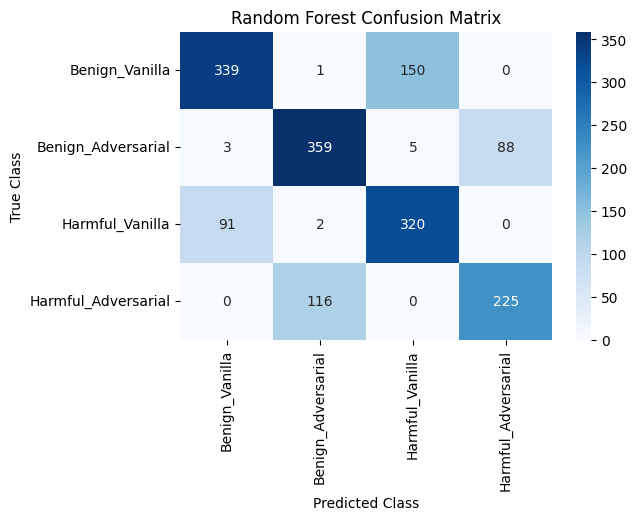

In [136]:
test_results = pd.DataFrame(columns=['Model', 'Test Accuracy', 'Test Macro F1'])

ml_models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model
}

class_names = [TARGET_NAMES[i] for i in range(4)]

for model_name, model in ml_models.items():
    print(f"\n==========================================")
    print(f" {model_name} Final Test Evaluation")
    print(f"==========================================")

    test_preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    test_results.loc[len(test_results)] = [model_name, acc, macro_f1]

    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names))

    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    os.makedirs("figures", exist_ok=True)
    plt.savefig(f"figures/confusion_matrix_{model_name.replace(' ', '_')}.png", dpi=200, bbox_inches='tight')
    plt.show()

### Neural Network Models Test Evaluation



 SimpleRNN Final Test Evaluation
Test Accuracy: 76.81%
Test Macro F1: 0.7592

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.82      0.91      0.86       490
 Benign_Adversarial       0.74      0.73      0.74       455
    Harmful_Vanilla       0.88      0.73      0.80       413
Harmful_Adversarial       0.63      0.67      0.65       341

           accuracy                           0.77      1699
          macro avg       0.77      0.76      0.76      1699
       weighted avg       0.77      0.77      0.77      1699



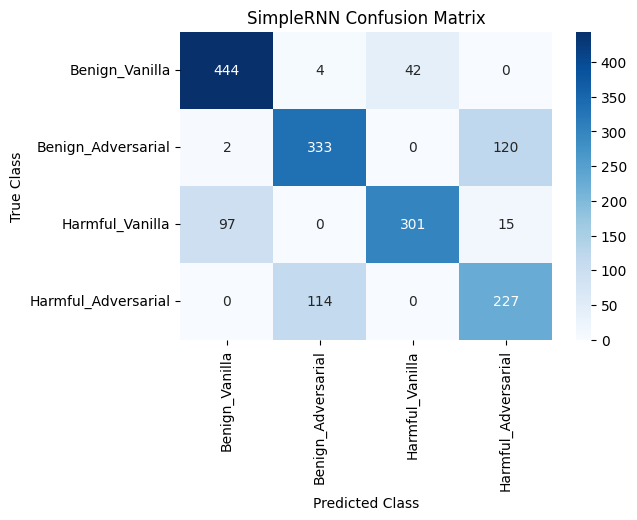


 GRU Final Test Evaluation
Test Accuracy: 81.75%
Test Macro F1: 0.8105

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.82      0.94      0.87       490
 Benign_Adversarial       0.80      0.82      0.81       455
    Harmful_Vanilla       0.91      0.74      0.82       413
Harmful_Adversarial       0.75      0.73      0.74       341

           accuracy                           0.82      1699
          macro avg       0.82      0.81      0.81      1699
       weighted avg       0.82      0.82      0.82      1699



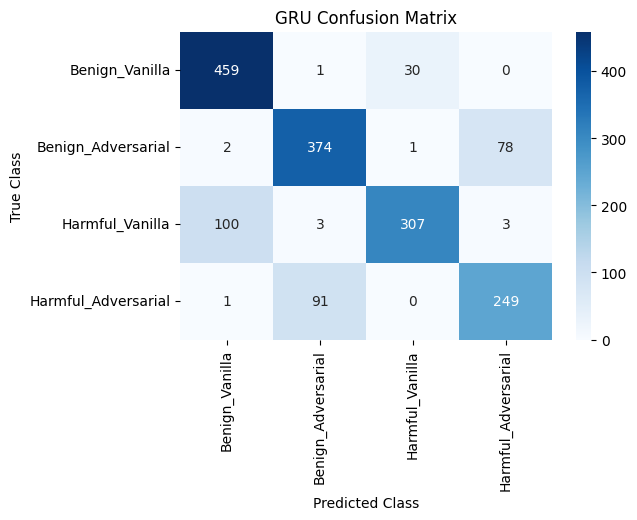


 LSTM Final Test Evaluation
Test Accuracy: 80.64%
Test Macro F1: 0.8004

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.82      0.91      0.86       490
 Benign_Adversarial       0.80      0.80      0.80       455
    Harmful_Vanilla       0.89      0.74      0.81       413
Harmful_Adversarial       0.72      0.75      0.74       341

           accuracy                           0.81      1699
          macro avg       0.81      0.80      0.80      1699
       weighted avg       0.81      0.81      0.81      1699



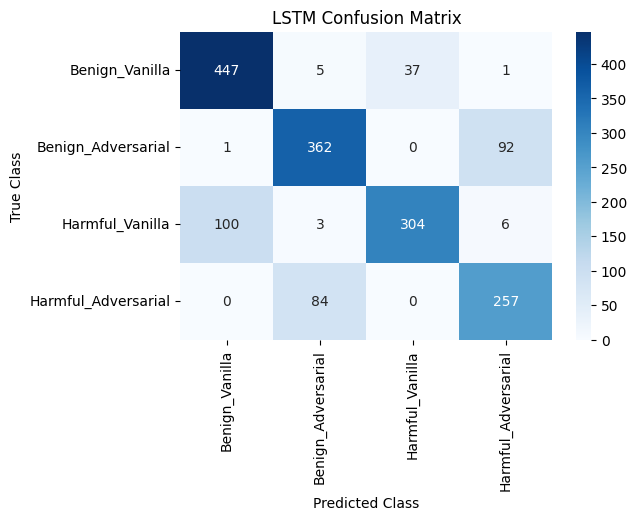


 Bi-SimpleRNN Final Test Evaluation
Test Accuracy: 76.40%
Test Macro F1: 0.7563

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.79      0.92      0.85       490
 Benign_Adversarial       0.78      0.70      0.74       455
    Harmful_Vanilla       0.88      0.66      0.76       413
Harmful_Adversarial       0.62      0.75      0.68       341

           accuracy                           0.76      1699
          macro avg       0.77      0.76      0.76      1699
       weighted avg       0.78      0.76      0.76      1699



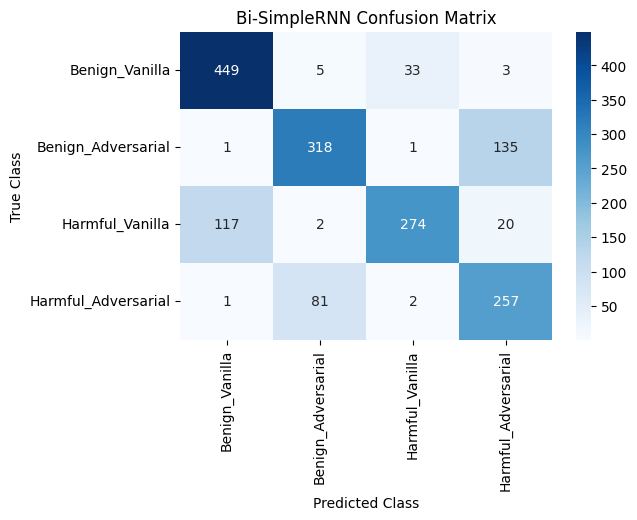


 Bi-GRU Final Test Evaluation
Test Accuracy: 81.17%
Test Macro F1: 0.8053

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.83      0.93      0.87       490
 Benign_Adversarial       0.80      0.78      0.79       455
    Harmful_Vanilla       0.90      0.75      0.82       413
Harmful_Adversarial       0.72      0.75      0.74       341

           accuracy                           0.81      1699
          macro avg       0.81      0.80      0.81      1699
       weighted avg       0.82      0.81      0.81      1699



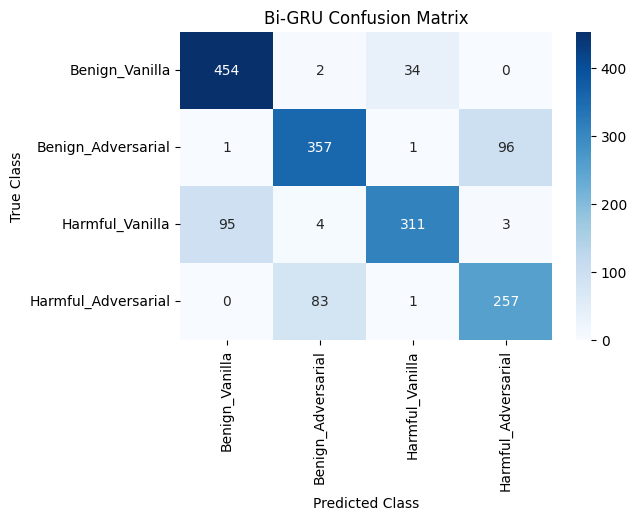


 Bi-LSTM Final Test Evaluation
Test Accuracy: 80.69%
Test Macro F1: 0.8021

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.82      0.91      0.86       490
 Benign_Adversarial       0.81      0.75      0.78       455
    Harmful_Vanilla       0.88      0.76      0.82       413
Harmful_Adversarial       0.70      0.79      0.75       341

           accuracy                           0.81      1699
          macro avg       0.81      0.80      0.80      1699
       weighted avg       0.81      0.81      0.81      1699



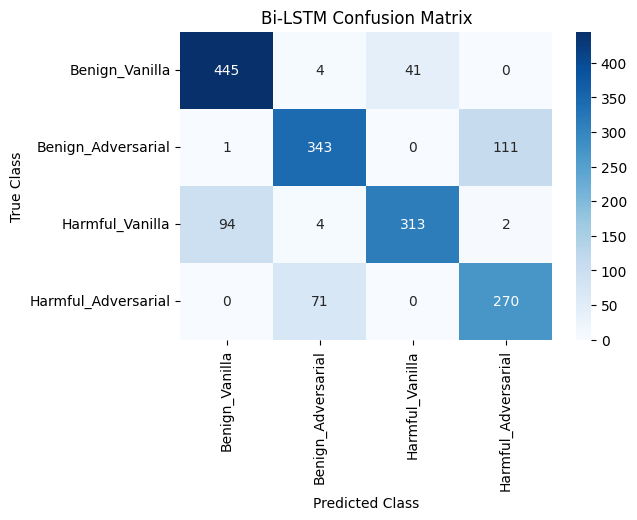

In [137]:
class_names = [TARGET_NAMES[i] for i in range(4)]

for model_name, model in best_models.items():
    print(f"\n==========================================")
    print(f" {model_name} Final Test Evaluation")
    print(f"==========================================")

    test_probs = model.predict(X_test_seq, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)

    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    test_results.loc[len(test_results)] = [model_name, acc, macro_f1]

    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names))

    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    os.makedirs("figures", exist_ok=True)
    plt.savefig(f"figures/confusion_matrix_{model_name.replace(' ', '-')}.png", dpi=200, bbox_inches='tight')
    plt.show()

### BERT Base Test Evaluation


 BERT Base Final Test Evaluation 
Test Accuracy: 85.40%
Test Macro F1: 0.8481

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.85      0.97      0.90       490
 Benign_Adversarial       0.83      0.85      0.84       455
    Harmful_Vanilla       0.96      0.79      0.87       413
Harmful_Adversarial       0.79      0.77      0.78       341

           accuracy                           0.85      1699
          macro avg       0.86      0.85      0.85      1699
       weighted avg       0.86      0.85      0.85      1699



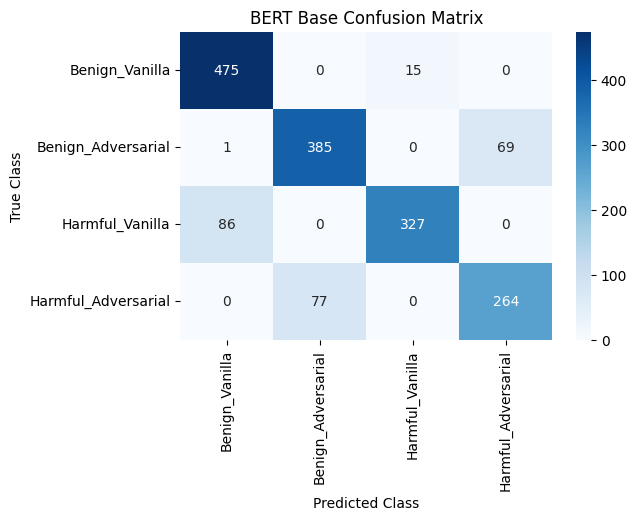

In [138]:
print("==========================================")
print(" BERT Base Final Test Evaluation ")
print("==========================================")

possible_pred_paths = [
    "data/bert_predictions.csv",
    "../data/bert_predictions.csv",
    "BERT Data/bert_predictions.csv",
    "bert_predictions.csv",
    "../BERT Data/bert_predictions.csv",
    "../bert_predictions.csv"
]

bert_preds_path = None
for p in possible_pred_paths:
    if os.path.exists(p):
        bert_preds_path = p
        break

if bert_preds_path is not None:
    bert_preds_df = pd.read_csv(bert_preds_path)
    bert_test_preds = bert_preds_df['bert_preds'].values

    acc = accuracy_score(y_test, bert_test_preds)
    macro_f1 = f1_score(y_test, bert_test_preds, average='macro')
    test_results.loc[len(test_results)] = ['BERT Base', acc, macro_f1]

    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, bert_test_preds, target_names=class_names))

    cm = confusion_matrix(y_test, bert_test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('BERT Base Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    os.makedirs("figures", exist_ok=True)
    plt.savefig("figures/confusion_matrix_BERT-Base.png", dpi=200, bbox_inches='tight')
    plt.show()

    if all(f'prob_{i}' in bert_preds_df.columns for i in range(4)):
        bert_test_probs = bert_preds_df[[f'prob_{i}' for i in range(4)]].values
    else:
        bert_test_probs = np.eye(4)[bert_test_preds]
else:
    print("Error: 'bert_predictions.csv' not found. Please upload or run the helper cell to generate it.")
    bert_test_probs = None



### Soft-Voting Ensemble Model

 Soft-Voting Ensemble (BERT + Best RNN + Best Traditional ML) 
Selected Traditional ML model for ensemble: Logistic Regression
Selected RNN for ensemble: GRU

 Soft-Voting Ensemble (BERT + GRU + Logistic Regression) -- Test Evaluation 
Test Accuracy: 85.05%
Test Macro F1: 0.8446

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.84      0.96      0.90       490
 Benign_Adversarial       0.83      0.85      0.84       455
    Harmful_Vanilla       0.95      0.78      0.86       413
Harmful_Adversarial       0.80      0.77      0.79       341

           accuracy                           0.85      1699
          macro avg       0.85      0.84      0.84      1699
       weighted avg       0.85      0.85      0.85      1699



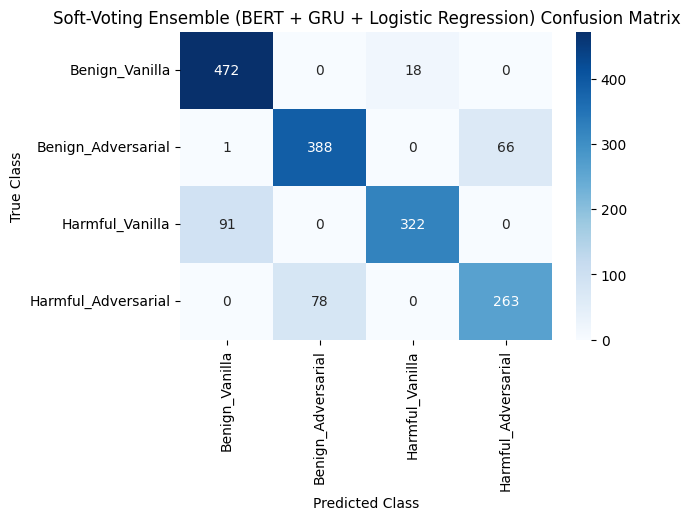

In [139]:
print("==========================================")
print(" Soft-Voting Ensemble (BERT + Best RNN + Best Traditional ML) ")
print("==========================================")

class_names = [TARGET_NAMES[i] for i in range(4)]

trad_models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model
}
trad_val_scores = {}
for name in trad_models:
    match_df = tuning_log[tuning_log['Model'] == name]
    if len(match_df) > 0:
        trad_val_scores[name] = match_df['Val F1'].max()

best_trad_name = max(trad_val_scores, key=trad_val_scores.get) if trad_val_scores else 'Logistic Regression'
best_trad_model = trad_models[best_trad_name]
trad_probs = best_trad_model.predict_proba(X_test_tfidf)
print(f"Selected Traditional ML model for ensemble: {best_trad_name}")

rnn_val_scores = {}
for name in best_models.keys():
    match_df = tuning_log[tuning_log['Model'] == name]
    if len(match_df) > 0:
        rnn_val_scores[name] = match_df['Val F1'].max()

if rnn_val_scores:
    best_rnn_key = max(rnn_val_scores, key=rnn_val_scores.get)
else:
    best_rnn_key = 'Bi-GRU' if 'Bi-GRU' in best_models else ('GRU' if 'GRU' in best_models else list(best_models.keys())[0])

best_rnn_model = best_models[best_rnn_key]
rnn_probs = best_rnn_model.predict(X_test_seq, verbose=0)
print(f"Selected RNN for ensemble: {best_rnn_key}")

possible_pred_paths = [
    "data/bert_predictions.csv",
    "../data/bert_predictions.csv",
    "BERT Data/bert_predictions.csv",
    "bert_predictions.csv",
    "../BERT Data/bert_predictions.csv",
    "../bert_predictions.csv"
]

bert_probs = None
for p in possible_pred_paths:
    if os.path.exists(p):
        bert_preds_df = pd.read_csv(p)
        if all(f'prob_{i}' in bert_preds_df.columns for i in range(4)):
            bert_probs = bert_preds_df[[f'prob_{i}' for i in range(4)]].values
        elif 'bert_preds' in bert_preds_df.columns:
            bert_probs = np.eye(4)[bert_preds_df['bert_preds'].values]
        break

if bert_probs is not None:
    ensemble_probs = (bert_probs + rnn_probs + trad_probs) / 3.0
    ensemble_preds = np.argmax(ensemble_probs, axis=1)

    ens_acc = accuracy_score(y_test, ensemble_preds)
    ens_macro_f1 = f1_score(y_test, ensemble_preds, average='macro')
    ensemble_label = f"Soft-Voting Ensemble (BERT + {best_rnn_key} + {best_trad_name})"

    print(f"\n==========================================")
    print(f" {ensemble_label} -- Test Evaluation ")
    print(f"==========================================")
    print(f"Test Accuracy: {ens_acc * 100:.2f}%")
    print(f"Test Macro F1: {ens_macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, ensemble_preds, target_names=class_names))

    cm = confusion_matrix(y_test, ensemble_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{ensemble_label} Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    os.makedirs("figures", exist_ok=True)
    plt.savefig("figures/confusion_matrix_ensemble.png", dpi=200, bbox_inches='tight')
    plt.show()

    test_results.loc[len(test_results)] = [ensemble_label, ens_acc, ens_macro_f1]
else:
    print("[Warning] BERT predictions not available for ensembling.")



### Final Model Comparison & Leaderboard


In [140]:
test_results = test_results.drop_duplicates(subset=['Model'], keep='last').reset_index(drop=True)

print("\n==========================================")
print(" Final Test Set Comparison Leaderboard ")
print("==========================================")
display(test_results.sort_values(by='Test Macro F1', ascending=False).reset_index(drop=True))


 Final Test Set Comparison Leaderboard 


,Model,Test Accuracy,Test Macro F1
0,BERT Base,0.854032,0.848086
1,Soft-Voting Ensemble (BERT + GRU + Logistic Re...,0.850500,0.844630
2,GRU,0.817540,0.810475
3,Bi-GRU,0.811654,0.805349
4,Bi-LSTM,0.806945,0.802078
5,LSTM,0.806357,0.800391
6,Logistic Regression,0.793408,0.789197
7,SimpleRNN,0.768099,0.759208
8,Bi-SimpleRNN,0.763979,0.756324
9,Random Forest,0.731607,0.728229


### Best vs. Worst Performing Model

In [141]:
best_row = test_results.loc[test_results['Test Macro F1'].idxmax()]
worst_row = test_results.loc[test_results['Test Macro F1'].idxmin()]

print("==========================================")
print(" Best vs. Worst Performing Model ")
print("==========================================")
print(f"Best:  {best_row['Model']}  |  Test Accuracy={best_row['Test Accuracy']*100:.2f}%  |  Test Macro F1={best_row['Test Macro F1']:.4f}")
print(f"Worst: {worst_row['Model']} |  Test Accuracy={worst_row['Test Accuracy']*100:.2f}%  |  Test Macro F1={worst_row['Test Macro F1']:.4f}")

 Best vs. Worst Performing Model 
Best:  BERT Base  |  Test Accuracy=85.40%  |  Test Macro F1=0.8481
Worst: Naive Bayes |  Test Accuracy=69.45%  |  Test Macro F1=0.6926


### Deep Learning Models: Training & Validation Curves Comparison
Visualizing training vs. validation loss and accuracy across all deep learning architectures (SimpleRNN, GRU, LSTM, Bi-SimpleRNN, Bi-GRU, Bi-LSTM, and BERT Base).

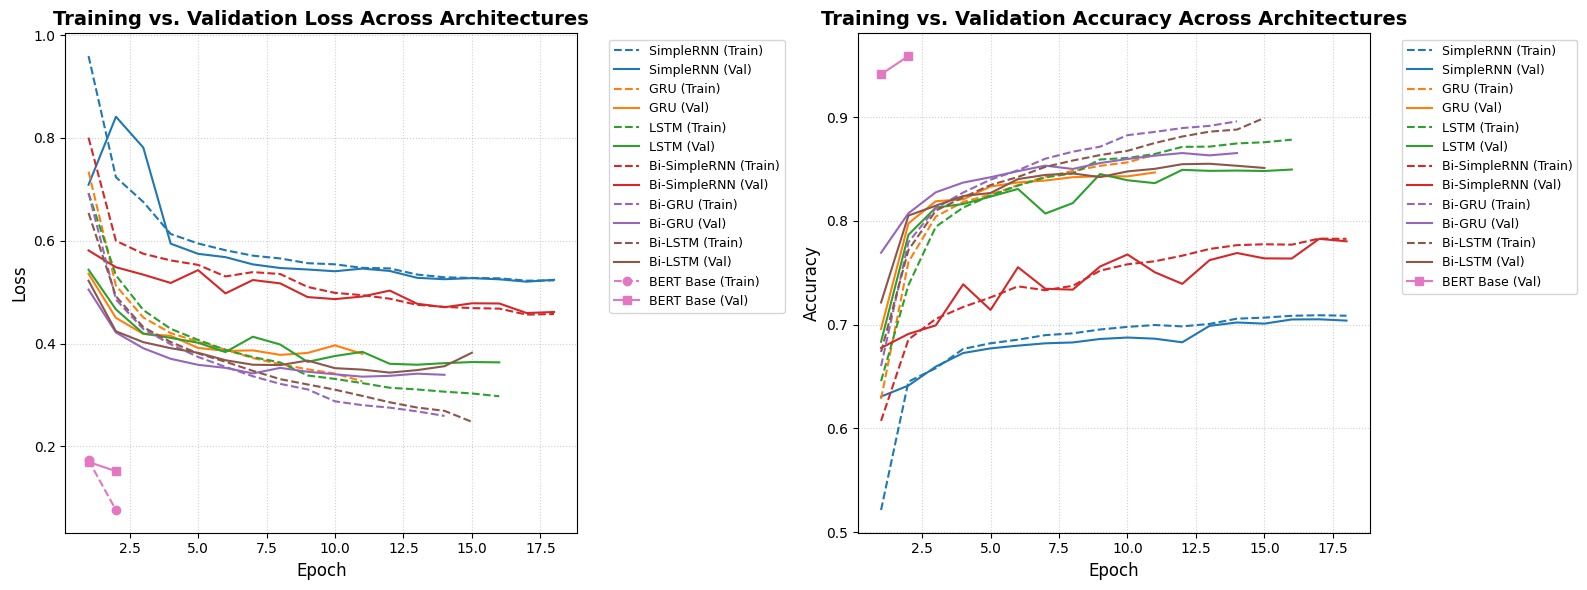

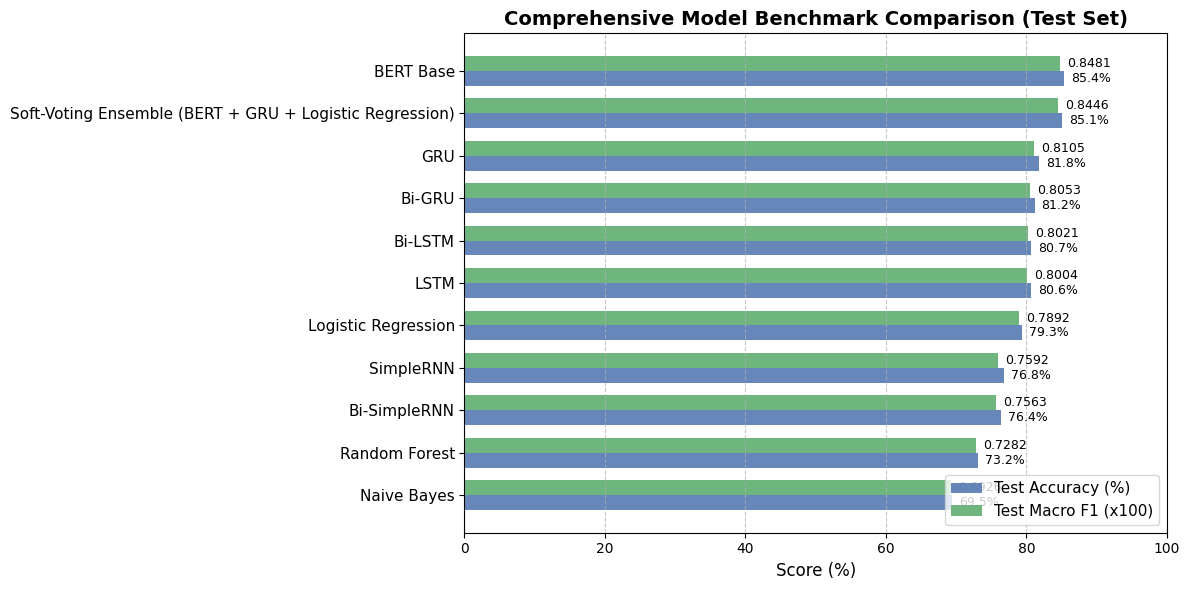

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


model_histories = {
    'SimpleRNN': simplernn_histories[0] if 'simplernn_histories' in locals() and len(simplernn_histories) > 0 else None,
    'GRU': gru_histories[0] if 'gru_histories' in locals() and len(gru_histories) > 0 else None,
    'LSTM': lstm_histories[0] if 'lstm_histories' in locals() and len(lstm_histories) > 0 else None,
    'Bi-SimpleRNN': bi_simplernn_histories[0] if 'bi_simplernn_histories' in locals() and len(bi_simplernn_histories) > 0 else None,
    'Bi-GRU': bi_gru_histories[0] if 'bi_gru_histories' in locals() and len(bi_gru_histories) > 0 else None,
    'Bi-LSTM': bi_lstm_histories[0] if 'bi_lstm_histories' in locals() and len(bi_lstm_histories) > 0 else None,
}

colors = {'SimpleRNN': '#1f77b4', 'GRU': '#ff7f0e', 'LSTM': '#2ca02c',
          'Bi-SimpleRNN': '#d62728', 'Bi-GRU': '#9467bd', 'Bi-LSTM': '#8c564b', 'BERT Base': '#e377c2'}


for name, hist in model_histories.items():
    if hist is not None and hasattr(hist, 'history'):
        epochs_range = range(1, len(hist.history['loss']) + 1)
        axes[0].plot(epochs_range, hist.history['loss'], label=f'{name} (Train)', color=colors.get(name, 'black'), linestyle='--')
        axes[0].plot(epochs_range, hist.history['val_loss'], label=f'{name} (Val)', color=colors.get(name, 'black'), linestyle='-')

        axes[1].plot(epochs_range, hist.history['accuracy'], label=f'{name} (Train)', color=colors.get(name, 'black'), linestyle='--')
        axes[1].plot(epochs_range, hist.history['val_accuracy'], label=f'{name} (Val)', color=colors.get(name, 'black'), linestyle='-')


bert_hist_paths = ["data/bert_history.csv", "../data/bert_history.csv", "BERT Data/bert_history.csv", "bert_history.csv", "../BERT Data/bert_history.csv", "../bert_history.csv"]
for bp in bert_hist_paths:
    if os.path.exists(bp):
        bert_h = pd.read_csv(bp)
        if 'train_loss' in bert_h.columns and 'val_loss' in bert_h.columns:
            axes[0].plot(bert_h['epoch'], bert_h['train_loss'], label='BERT Base (Train)', color=colors['BERT Base'], linestyle='--', marker='o')
            axes[0].plot(bert_h['epoch'], bert_h['val_loss'], label='BERT Base (Val)', color=colors['BERT Base'], linestyle='-', marker='s')
        if 'val_accuracy' in bert_h.columns:
            axes[1].plot(bert_h['epoch'], bert_h['val_accuracy'], label='BERT Base (Val)', color=colors['BERT Base'], linestyle='-', marker='s')
        break

axes[0].set_title('Training vs. Validation Loss Across Architectures', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].set_title('Training vs. Validation Accuracy Across Architectures', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig('figures/model_training_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


plt.figure(figsize=(12, 6))
sorted_results = test_results.sort_values(by='Test Macro F1', ascending=True)
y_pos = np.arange(len(sorted_results))
bar_width = 0.35

plt.barh(y_pos - bar_width/2, sorted_results['Test Accuracy'] * 100, bar_width, label='Test Accuracy (%)', color='#4C72B0', alpha=0.85)
plt.barh(y_pos + bar_width/2, sorted_results['Test Macro F1'] * 100, bar_width, label='Test Macro F1 (x100)', color='#55A868', alpha=0.85)

plt.yticks(y_pos, sorted_results['Model'], fontsize=11)
plt.xlabel('Score (%)', fontsize=12)
plt.title('Comprehensive Model Benchmark Comparison (Test Set)', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, (_, row) in enumerate(sorted_results.iterrows()):
    plt.text(row['Test Accuracy'] * 100 + 1, i - bar_width/2, f"{row['Test Accuracy']*100:.1f}%", va='center', fontsize=9)
    plt.text(row['Test Macro F1'] * 100 + 1, i + bar_width/2, f"{row['Test Macro F1']:.4f}", va='center', fontsize=9)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig('figures/model_benchmark_barchart.png', dpi=200, bbox_inches='tight')
plt.show()